In [1]:
#!pip install alpaca-py #newer base
#!pip install alpaca-trade-api
#!pip install mplfinance

In [2]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from datetime import datetime
import pandas as pd


In [3]:
# Alpaca API credentials
API_KEY = "PKP6G2PCSLR7KABZBU9Z"
API_SECRET = "mPNf9KoilrmoMdz4MedQdeaZWxda3D1YjgCIJbjd"

client = StockHistoricalDataClient(API_KEY, API_SECRET)

In [4]:
SUPPORTED_TIMEFRAMES = {
    "Minute": [1, 5, 15],
    "Hour": [1],
    "Day": [1]
}

#i belive i can call multiple tickers at the same time
# i can also call multiple timeframes at the same time

def get_stock_data(symbol: str, start_date: str, end_date: str,
                   timeframe_unit: str = "Day", multiplier: int = 1):
    if timeframe_unit not in SUPPORTED_TIMEFRAMES:
        raise ValueError(f"Unsupported timeframe unit: {timeframe_unit}")
    if multiplier not in SUPPORTED_TIMEFRAMES[timeframe_unit]:
        raise ValueError(f"Unsupported multiplier '{multiplier}' for '{timeframe_unit}'")

    unit_enum = TimeFrameUnit[timeframe_unit]
    alpaca_timeframe = TimeFrame(multiplier, unit_enum)

    request_params = StockBarsRequest(
        symbol_or_symbols=[symbol],
        timeframe=alpaca_timeframe,
        start=datetime.strptime(start_date, "%Y-%m-%d"),
        end=datetime.strptime(end_date, "%Y-%m-%d")
    )

    bars = client.get_stock_bars(request_params)
    df = bars.df

    # Handle both flat and MultiIndex column cases
    if isinstance(df.columns, pd.MultiIndex):
        if symbol in df.columns.levels[0]:
            df = df.xs(symbol, axis=1, level=0)
        else:
            raise KeyError(f"Symbol '{symbol}' not found in returned data columns.")
    
    # Check for required columns and raise helpful error if missing
    required_cols = ['open', 'high', 'low', 'close', 'volume']
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in data: {missing}\nAvailable columns: {df.columns.tolist()}")

    # Clean non-trading days
    df = df.dropna(subset=['open', 'high', 'low', 'close', 'volume'])

    # Drop fake/no-trade rows
    df = df[~(
        (df['open'] == df['high']) &
        (df['high'] == df['low']) &
        (df['low'] == df['close']) &
        (df['volume'] == 0)
    )]

    return df[required_cols]



In [11]:
def plot_candlestick_with_volume(df, symbol: str):
    # If MultiIndex (e.g., (symbol, datetime)), reduce to datetime index
    if isinstance(df.index, pd.MultiIndex):
        df = df.reset_index(level=0, drop=True)

    # Ensure index is datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Reset index for plotting
    df_plot = df.copy().reset_index()
    df_plot.rename(columns={df_plot.columns[0]: 'timestamp'}, inplace=True)

    # Use integer x positions (0, 1, 2, ...) to enforce uniform spacing
    df_plot['x'] = range(len(df_plot))

    # Build OHLC data
    quotes = list(zip(
        df_plot['x'],
        df_plot['open'],
        df_plot['high'],
        df_plot['low'],
        df_plot['close']
    ))

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

    candlestick_ohlc(ax1, quotes, width=0.6, colorup='g', colordown='r', alpha=0.8)
    ax1.set_title(f'{symbol} Candlestick Chart')
    ax1.set_ylabel('Price')
    ax1.grid(True)

    # Volume bars
    ax2.bar(df_plot['x'], df_plot['volume'], color='gray', width=0.6)
    ax2.set_ylabel('Volume')
    ax2.grid(True)

    # Set x-ticks to timestamps
    tick_interval = max(1, len(df_plot) // 10)
    ax2.set_xticks(df_plot['x'][::tick_interval])
    ax2.set_xticklabels(df_plot['timestamp'].dt.strftime('%Y-%m-%d')[::tick_interval], rotation=45)

    plt.tight_layout()
    plt.show()


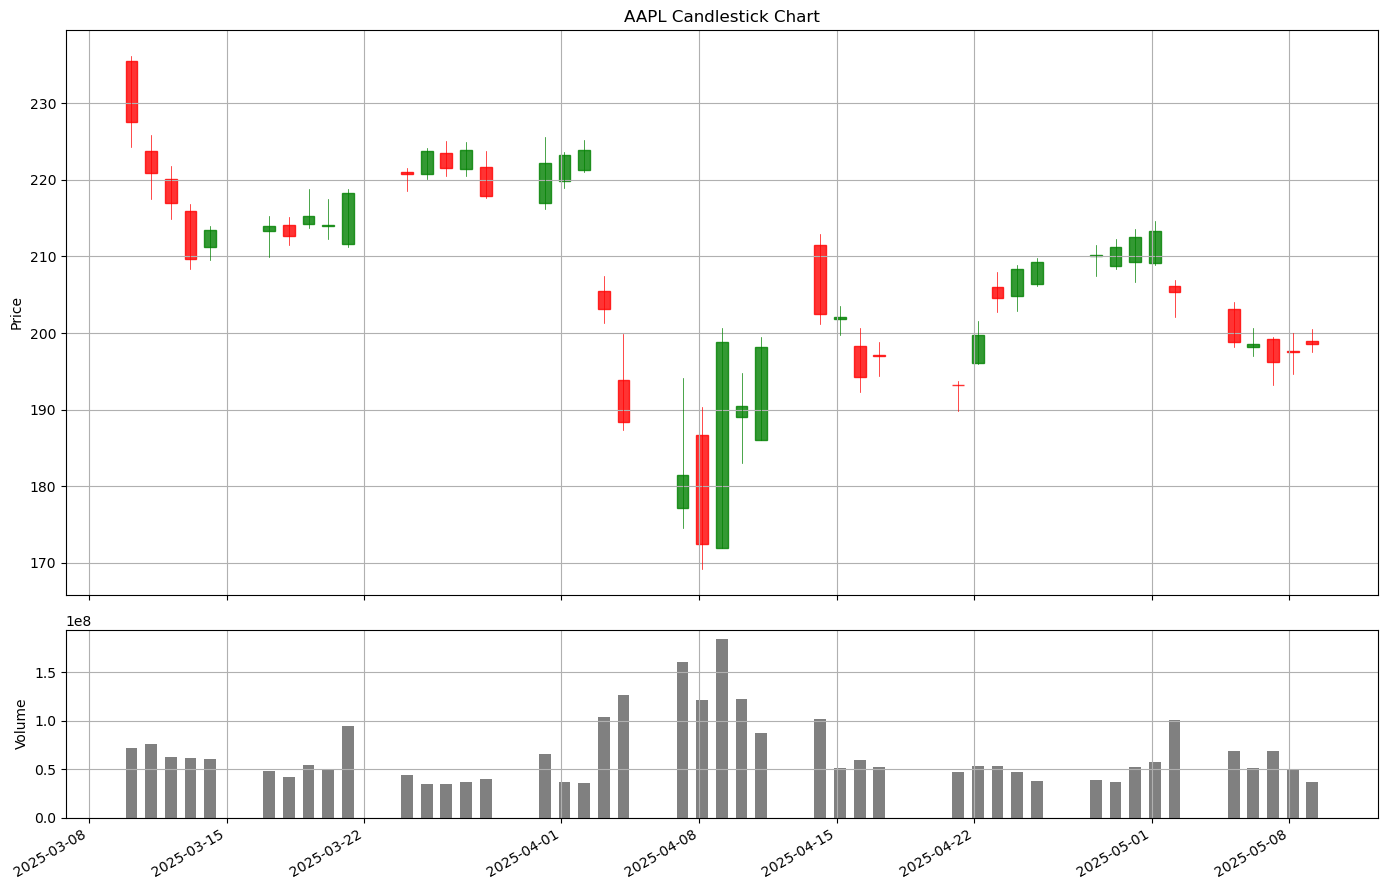

In [7]:
# Example usage
symbol = "AAPL"
start_date = "2025-03-10"
end_date = "2025-05-10"
timeframe_unit = "Day"  # or "Minute", "Hour"
multiplier = 1
# Get stock data
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)
# Plot candlestick chart with volume
plot_candlestick_with_volume(df, symbol)

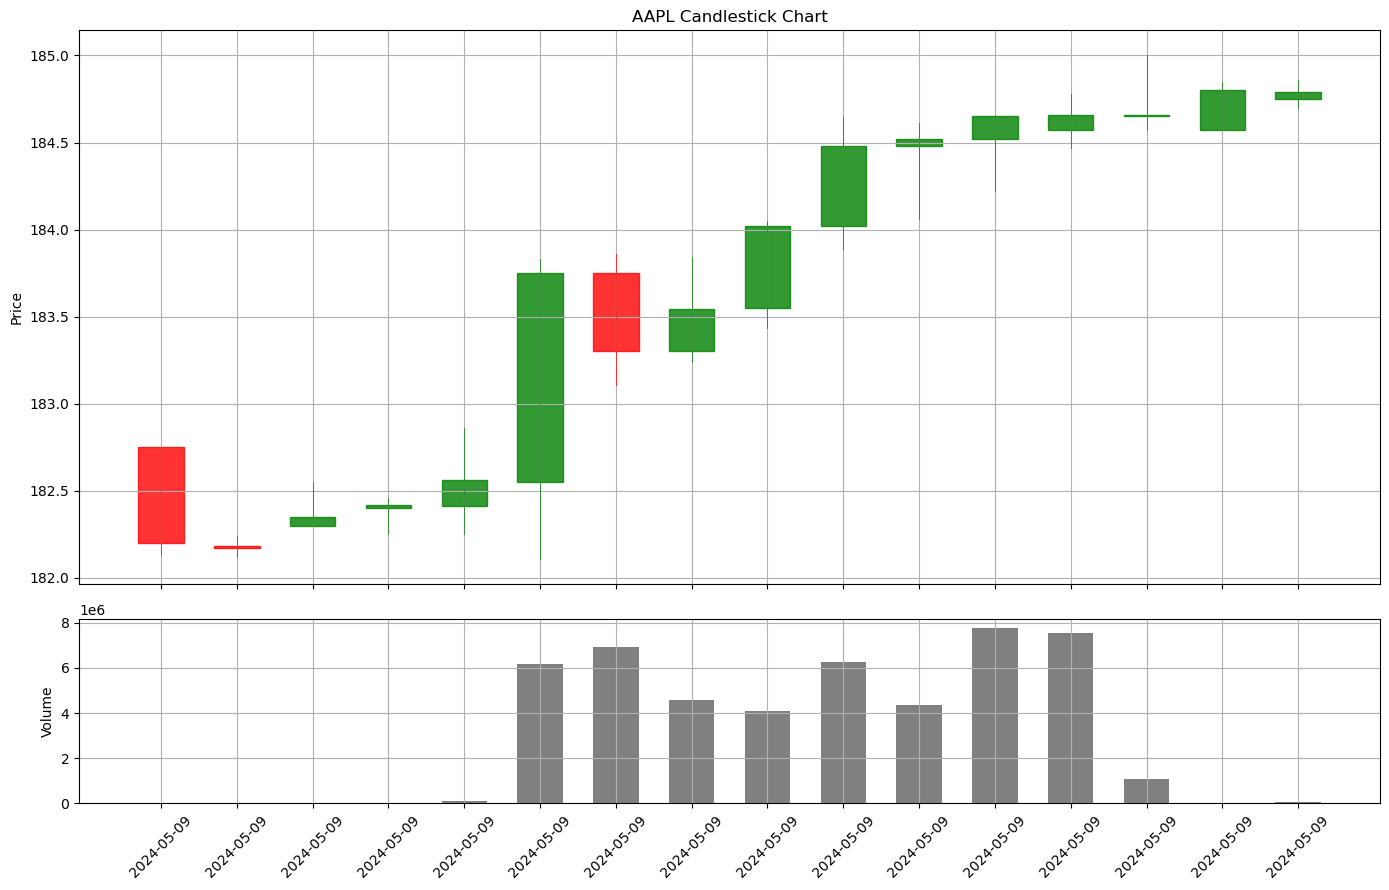

In [10]:
# Example usage
symbol = "AAPL"
start_date = "2024-05-9"
end_date = "2024-05-10"
timeframe_unit = "Hour"  # or "Minute", "Hour"
multiplier = 1
# Get stock data
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)
# Plot candlestick chart with volume
plot_candlestick_with_volume(df, symbol)